# Phase 2 — Low-SNR Robustness Experiment

Adds AWGN to signal chunks post-chunking at SNR ∈ {0, 5, 10, 15, 20} dB,
then evaluates all detectors to produce a **Pd vs SNR** curve at fixed Pfa = 0.05.

**Setup:**
- Threshold calibrated from **clean** background (no noise added to noise segments)
- AWGN added only to signal chunks (post-chunking — limitation noted in paper)
- All detectors: Energy, Wavelet, Cyclo (blind), Cascade (mbl=50)

**Expected runtime: ~40–60 min**  
Output → `results/review_1/low_snr_pd_curve.png`

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from dotenv import load_dotenv
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / "src"))

from rfml_uav.drone_rf.consts import BUI, FS_HZ
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label
from rfml_uav.signal_detection.methods import energy_detector, wavelet_detector, cyclo_detector
from rfml_uav.signal_detection.cascade import aggregate_bursts

load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"
OUT = ROOT / "results" / "review_1"
OUT.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

BG_BUI     = "00000"
FIXED_PFA  = 0.05
FIXED_MBL  = 50
FIXED_NFFT = 512
SNR_VALS   = [0, 5, 10, 15, 20]  # dB

print(f"ROOT         : {ROOT}")
print(f"CHUNKED_PATH : {CHUNKED_PATH}")
print(f"SNR values   : {SNR_VALS} dB")

ROOT         : /home/ivan/work/ml/rfml-uav
CHUNKED_PATH : /home/ivan/work/ml/rfml-uav/data/drone-rf/chunked
SNR values   : [0, 5, 10, 15, 20] dB


## Helpers

In [2]:
def add_awgn(x, snr_db):
    """Add AWGN to achieve target SNR relative to signal chunk power."""
    p_signal = np.mean(x ** 2)
    if p_signal == 0:
        return x.copy()
    p_noise = p_signal / (10 ** (snr_db / 10))
    return x + np.random.randn(len(x)) * np.sqrt(p_noise)


def duration_constrained_score(scores, min_duration=0.10):
    chunk_dur = 4000 / FS_HZ
    k = max(1, int(np.ceil(min_duration / chunk_dur)))
    if len(scores) <= k:
        return float(np.mean(scores))
    return float(np.mean(np.sort(scores)[-k:]))


def cascade_segment_score(files, thr, mbl, nfft):
    """Run cascade on a list of .npz files, return (score, cyclo_invoked)."""
    all_scores, invoked = [], False
    for fp in files:
        chunks = np.load(fp)["arr_0"]
        decisions = [energy_detector(x) >= thr for x in chunks]
        bursts = aggregate_bursts(decisions, min_len=mbl)
        if bursts:
            invoked = True
            c_scores = [
                cyclo_detector(np.concatenate(chunks[b0:b1]), fs=FS_HZ, Nfft=nfft)
                for b0, b1 in bursts
            ]
            all_scores.append(max(c_scores))
    return max(all_scores) if all_scores else 0.0, invoked

## Energy threshold from clean background

Calibrated once on clean (no AWGN) background data — represents a system calibrated in a noise-free environment.

In [3]:
print("Estimating energy threshold from clean background...")
bg_scores = []
for seg in range(get_segment_count(BG_BUI)):
    for fp in sorted(glob(str(CHUNKED_PATH / f"{BG_BUI}*_{seg}.npz"))):
        chunks = np.load(fp)["arr_0"]
        bg_scores.extend(energy_detector(x) for x in chunks)

thr_energy = float(np.percentile(bg_scores, 100 * (1 - FIXED_PFA)))
print(f"thr_energy = {thr_energy:.6f}  (Pfa = {FIXED_PFA})")

Estimating energy threshold from clean background...
thr_energy = 14.769512  (Pfa = 0.05)


## SNR sweep

For each SNR value:
1. Add AWGN to every signal chunk at the specified SNR
2. Run all four detectors on the noisy signal chunks
3. Run all four detectors on clean background chunks (Pfa reference)
4. Compute Pd at Pfa = 0.05 operating point

**Note:** Noise added post-chunking. Raw waveform preprocessing (bandpass, normalization)
was applied before chunking in the DroneRF pipeline and is NOT re-run here.
This is a stated limitation in the paper.

In [4]:
SIGNAL_BUIS = [b for b in BUI if get_binary_label(b) == 1]
NOISE_BUIS  = [b for b in BUI if get_binary_label(b) == 0]

methods = ["Energy", "Wavelet", "Cyclo", "Cascade"]
records = []

for snr_db in SNR_VALS:
    print(f"\n{'='*50}")
    print(f"SNR = {snr_db} dB")
    print(f"{'='*50}")

    # Collect segment-level scores for signal (noisy) and noise (clean)
    seg_scores = {m: [] for m in methods}
    seg_labels = []

    # ── Signal segments (with AWGN) ──────────────────────────────────────
    for bui in tqdm(SIGNAL_BUIS, desc=f"  Signal ({snr_db} dB)"):
        for seg in range(get_segment_count(bui)):
            files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
            if not files:
                continue

            e_scores, w_scores, c_scores = [], [], []
            casc_file_scores, casc_invoked = [], False

            for fp in files:
                raw_chunks = np.load(fp)["arr_0"]
                noisy = np.array([add_awgn(x, snr_db) for x in raw_chunks])

                e_scores.extend(energy_detector(x)          for x in noisy)
                w_scores.extend(wavelet_detector(x)         for x in noisy)
                c_scores.extend(cyclo_detector(x, fs=FS_HZ) for x in noisy)

                # Cascade on noisy chunks
                decisions = [energy_detector(x) >= thr_energy for x in noisy]
                bursts = aggregate_bursts(decisions, min_len=FIXED_MBL)
                if bursts:
                    casc_invoked = True
                    casc_file_scores.append(max(
                        cyclo_detector(np.concatenate(noisy[b0:b1]), fs=FS_HZ, Nfft=FIXED_NFFT)
                        for b0, b1 in bursts
                    ))

            seg_scores["Energy"].append(duration_constrained_score(e_scores))
            seg_scores["Wavelet"].append(duration_constrained_score(w_scores))
            seg_scores["Cyclo"].append(duration_constrained_score(c_scores))
            seg_scores["Cascade"].append(max(casc_file_scores) if casc_file_scores else 0.0)
            seg_labels.append(1)

    # ── Noise segments (clean, for Pfa reference) ─────────────────────────
    for bui in tqdm(NOISE_BUIS, desc=f"  Noise (clean)"):
        for seg in range(get_segment_count(bui)):
            files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
            if not files:
                continue

            e_scores, w_scores, c_scores = [], [], []
            casc_file_scores = []

            for fp in files:
                chunks = np.load(fp)["arr_0"]
                e_scores.extend(energy_detector(x)          for x in chunks)
                w_scores.extend(wavelet_detector(x)         for x in chunks)
                c_scores.extend(cyclo_detector(x, fs=FS_HZ) for x in chunks)

                decisions = [energy_detector(x) >= thr_energy for x in chunks]
                bursts = aggregate_bursts(decisions, min_len=FIXED_MBL)
                if bursts:
                    casc_file_scores.append(max(
                        cyclo_detector(np.concatenate(chunks[b0:b1]), fs=FS_HZ, Nfft=FIXED_NFFT)
                        for b0, b1 in bursts
                    ))

            seg_scores["Energy"].append(duration_constrained_score(e_scores))
            seg_scores["Wavelet"].append(duration_constrained_score(w_scores))
            seg_scores["Cyclo"].append(duration_constrained_score(c_scores))
            seg_scores["Cascade"].append(max(casc_file_scores) if casc_file_scores else 0.0)
            seg_labels.append(0)

    seg_labels = np.array(seg_labels)
    row = {"snr_db": snr_db}
    for method in methods:
        s = np.array(seg_scores[method])
        fpr, tpr, _ = roc_curve(seg_labels, s)
        roc_auc = auc(fpr, tpr)
        ok = np.where(fpr <= FIXED_PFA)[0]
        i  = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)
        row[f"{method}_Pd"]  = float(tpr[i])
        row[f"{method}_AUC"] = roc_auc
        print(f"  {method:10s}: Pd={float(tpr[i]):.3f}  AUC={roc_auc:.3f}")
    records.append(row)

df = pd.DataFrame(records)
csv_path = OUT / "low_snr_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")
print(df.to_string(index=False))


SNR = 0 dB


  Noise (clean): 100%|██████████| 1/1 [01:25<00:00, 85.33s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

SNR = 5 dB


  Noise (clean): 100%|██████████| 1/1 [01:25<00:00, 85.56s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

SNR = 10 dB


...

  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

SNR = 15 dB


  Noise (clean): 100%|██████████| 1/1 [01:24<00:00, 85.00s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

SNR = 20 dB


  Noise (clean): 100%|██████████| 1/1 [01:24<00:00, 84.92s/it]

  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/low_snr_results.csv
 snr_db  Energy_Pd  Energy_AUC  Wavelet_Pd  Wavelet_AUC  Cyclo_Pd  Cyclo_AUC  Cascade_Pd  Cascade_AUC
      0        1.0         1.0         1.0          1.0       1.0        1.0         1.0          1.0
      5        1.0         1.0         1.0          1.0       1.0        1.0         1.0          1.0
     10        1.0         1.0         1.0          1.0       1.0        1.0         1.0          1.0
     15        1.0         1.0         1.0          1.0       1.0        1.0         1.0          1.0
     20        1.0         1.0         1.0          1.0       1.0        1.0         1.0          1.0


## Pd vs SNR curve

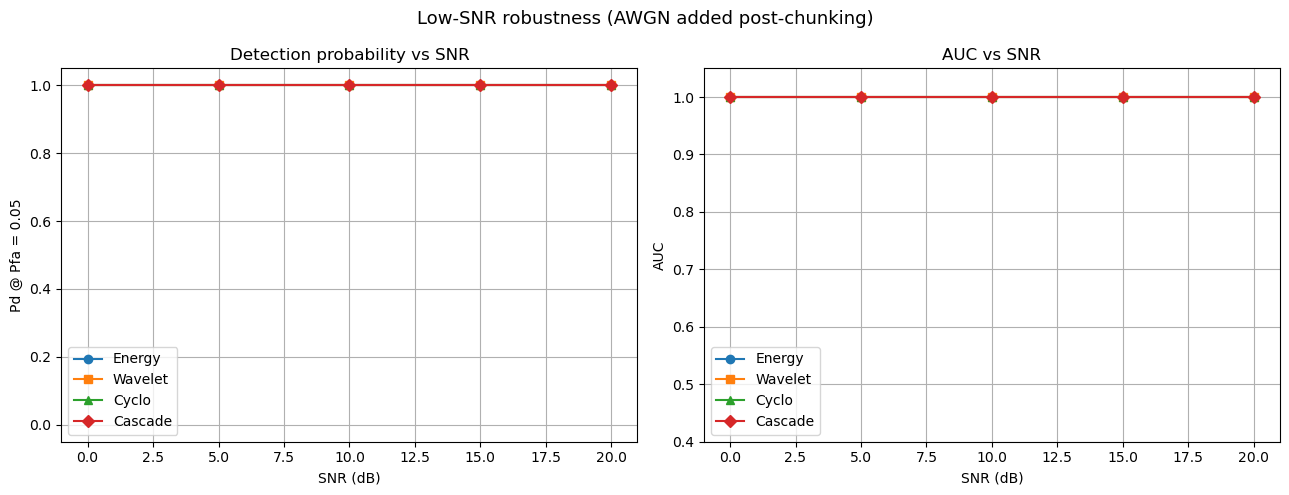

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/low_snr_pd_curve.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"Energy": "#1f77b4", "Wavelet": "#ff7f0e", "Cyclo": "#2ca02c", "Cascade": "#d62728"}
markers = {"Energy": "o", "Wavelet": "s", "Cyclo": "^", "Cascade": "D"}

# Pd vs SNR
ax = axes[0]
for method in methods:
    ax.plot(SNR_VALS, df[f"{method}_Pd"], marker=markers[method],
            color=colors[method], label=method)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("Detection probability vs SNR")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True)

# AUC vs SNR
ax = axes[1]
for method in methods:
    ax.plot(SNR_VALS, df[f"{method}_AUC"], marker=markers[method],
            color=colors[method], label=method)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("AUC")
ax.set_title("AUC vs SNR")
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.grid(True)

fig.suptitle("Low-SNR robustness (AWGN added post-chunking)", fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "low_snr_pd_curve.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'low_snr_pd_curve.png'}")

## Limitation note (for paper Section 6)

> AWGN is added **after** chunking. The DroneRF preprocessing pipeline (bandpass filtering,
> normalization, I/Q separation) was applied before chunking and is not re-run for each SNR level.
> This means the low-SNR evaluation does not capture preprocessing effects at low SNR.
> Future work should include end-to-end evaluation with noise injection prior to preprocessing.